In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
from pathlib import Path

SRC = Path("/content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5291Bbox-Complete")
DST = Path("/content/SnakeDataset")

if not DST.exists():   # 🔥 CHỈ COPY NẾU CHƯA CÓ
    shutil.copytree(SRC, DST)
    print("Dataset copied to /content")
else:
    print("Dataset already exists in /content, skip copying")


Dataset copied to /content


In [ ]:
import yaml

yaml_path = DST / "data.yaml"
data = yaml.safe_load(yaml_path.read_text())

data["train"] = str(DST / "train" / "images")
data["val"]   = str(DST / "valid" / "images")
data["test"]  = str(DST / "test" / "images")

yaml_path.write_text(yaml.safe_dump(data, sort_keys=False))
print("data.yaml updated for local training")


data.yaml updated for local training


In [ ]:
# Nếu thiếu thư viện:
# !pip -q install pyyaml opencv-python

import os
from pathlib import Path
import yaml
from collections import Counter
import csv

DATASET_ROOT = Path("/content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5291Bbox-Complete")
DATA_YAML = DATASET_ROOT / "data.yaml"

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def load_data_yaml(data_yaml_path: Path):
    with open(data_yaml_path, "r", encoding="utf-8") as f:
        data = yaml.safe_load(f)

    names = data.get("names")
    if isinstance(names, list):
        id2name = {i: n for i, n in enumerate(names)}
    elif isinstance(names, dict):
        id2name = {int(k): v for k, v in names.items()}
    else:
        raise ValueError("data.yaml missing 'names' or wrong format.")

    nc = int(data.get("nc", len(id2name)))
    if nc != len(id2name):
        print(f"[WARN] nc={nc} but names has {len(id2name)} items. Using names length={len(id2name)}.")
    return data, id2name

def expected_class_from_filename(stem: str, class_names):
    stem_lower = stem.lower()
    candidates = [c for c in class_names if c.lower() in stem_lower]
    if not candidates:
        return None
    candidates.sort(key=len, reverse=True)  # match dài nhất
    return candidates[0]

def parse_yolo_label(label_path: Path):
    """
    Return list of (cls_id, x, y, w, h), status.
    """
    boxes = []
    if not label_path.exists():
        return boxes, "MISSING"

    txt = label_path.read_text(encoding="utf-8", errors="ignore").strip()
    if not txt:
        return boxes, "EMPTY"

    for ln, line in enumerate(txt.splitlines(), start=1):
        parts = line.strip().split()
        if len(parts) < 5:
            return boxes, f"INVALID_LINE_{ln}"
        try:
            cls = int(float(parts[0]))
            x, y, w, h = map(float, parts[1:5])
            boxes.append((cls, x, y, w, h))
        except Exception:
            return boxes, f"PARSE_ERROR_LINE_{ln}"

    return boxes, "OK"

def audit_dataset(root: Path, data_yaml_path: Path, splits=("train", "valid", "test")):
    _, id2name = load_data_yaml(data_yaml_path)
    class_names = list(id2name.values())
    n_classes = len(class_names)

    issues = {
        "missing_label": [],
        "empty_label": [],
        "invalid_label": [],
        "missing_image": [],
        "bad_class_id": [],
        "filename_class_mismatch": [],
        "no_class_in_filename": [],
    }

    counts = {
        "images_total": 0,
        "labels_total": 0,
        "objects_total": 0,
        "objects_per_class": Counter(),
        "label_status": Counter(),
    }

    summary = {}

    for split in splits:
        img_dir = root / split / "images"
        lbl_dir = root / split / "labels"

        if not img_dir.exists():
            summary[split] = f"MISSING images dir: {img_dir}"
            continue
        if not lbl_dir.exists():
            summary[split] = f"MISSING labels dir: {lbl_dir}"
            continue

        images = [p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS]
        labels = list(lbl_dir.glob("*.txt"))

        counts["images_total"] += len(images)
        counts["labels_total"] += len(labels)

        image_stems = {p.stem for p in images}

        # Image -> Label checks
        for img_path in images:
            label_path = lbl_dir / f"{img_path.stem}.txt"
            boxes, status = parse_yolo_label(label_path)
            counts["label_status"][status] += 1

            if status == "MISSING":
                issues["missing_label"].append(str(img_path))
                continue
            if status == "EMPTY":
                issues["empty_label"].append(str(img_path))
                continue
            if status != "OK":
                issues["invalid_label"].append((str(img_path), status))
                continue

            # Count objects + validate class ids
            for (cls, x, y, w, h) in boxes:
                counts["objects_total"] += 1
                if cls < 0 or cls >= n_classes:
                    issues["bad_class_id"].append((str(img_path), cls))
                    continue
                counts["objects_per_class"][id2name[cls]] += 1

            # Heuristic: filename class vs label class
            expected = expected_class_from_filename(img_path.stem, class_names)
            if expected is None:
                issues["no_class_in_filename"].append(str(img_path))
                continue

            unique_cls = sorted({b[0] for b in boxes})
            unique_names = [id2name[c] for c in unique_cls if 0 <= c < n_classes]

            if len(unique_names) == 1:
                if unique_names[0] != expected:
                    issues["filename_class_mismatch"].append({
                        "image": str(img_path),
                        "expected_from_name": expected,
                        "label_class": unique_names[0],
                    })
            else:
                # multi-class: expected must be present
                if expected not in unique_names:
                    issues["filename_class_mismatch"].append({
                        "image": str(img_path),
                        "expected_from_name": expected,
                        "label_classes": unique_names,
                    })

        # Label -> Image checks
        for lb in labels:
            if lb.stem not in image_stems:
                issues["missing_image"].append(str(lb))

        summary[split] = f"OK ({len(images)} images, {len(labels)} labels)"

    return summary, counts, issues

summary, counts, issues = audit_dataset(DATASET_ROOT, DATA_YAML)

print("=== SUMMARY ===")
for k, v in summary.items():
    print(f"{k:5s}: {v}")

print("\n=== COUNTS ===")
print("Images total :", counts["images_total"])
print("Labels total :", counts["labels_total"])
print("Objects total:", counts["objects_total"])
print("Label status :", dict(counts["label_status"]))

print("\n=== TOP 10 CLASSES (by object count) ===")
for cls, cnt in counts["objects_per_class"].most_common(10):
    print(f"{cls:25s} {cnt}")

print("\n=== ISSUES (counts) ===")
for k, v in issues.items():
    print(f"{k:25s}: {len(v)}")

# Export CSV of suspicious items
out_csv = DATASET_ROOT / "snake_label_audit.csv"
rows = []

for item in issues["filename_class_mismatch"]:
    rows.append({
        "type": "filename_class_mismatch",
        "image": item.get("image"),
        "expected_from_name": item.get("expected_from_name"),
        "label_class_or_classes": item.get("label_class") or ",".join(item.get("label_classes", [])),
    })

for img in issues["missing_label"]:
    rows.append({"type":"missing_label", "image": img})

for img in issues["empty_label"]:
    rows.append({"type":"empty_label", "image": img})

for img, status in issues["invalid_label"]:
    rows.append({"type":"invalid_label", "image": img, "status": status})

for img, cls in issues["bad_class_id"]:
    rows.append({"type":"bad_class_id", "image": img, "class_id": cls})

for lb in issues["missing_image"]:
    rows.append({"type":"missing_image_for_label", "label": lb})

fieldnames = sorted({k for r in rows for k in r.keys()}) if rows else ["type", "image"]
with open(out_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    if rows:
        writer.writerows(rows)

print("\nSaved audit CSV to:", out_csv)


=== SUMMARY ===
train: OK (4795 images, 4795 labels)
valid: OK (265 images, 265 labels)
test : OK (231 images, 231 labels)

=== COUNTS ===
Images total : 5291
Labels total : 5291
Objects total: 5295
Label status : {'OK': 5291}

=== TOP 10 CLASSES (by object count) ===
khiem_vach                273
ran_roi                   270
cap_nia_bac               267
cap_nia_nam               264
luc_nua                   262
ran_dai_lon               260
luc_cuom                  256
luc_xanh_duoi_do          255
ran_ri_ca                 255
luc_xanh                  254

=== ISSUES (counts) ===
missing_label            : 0
empty_label              : 0
invalid_label            : 0
missing_image            : 0
bad_class_id             : 0
filename_class_mismatch  : 0
no_class_in_filename     : 1270

Saved audit CSV to: /content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5291Bbox-Complete/snake_label_audit.csv


In [ ]:
print("=== 5 IMAGES WITH FILENAME ↔ LABEL MISMATCH ===")
for i, it in enumerate(issues["filename_class_mismatch"][:5], 1):
    print(f"{i}. {it['image']}")
    print(f"   expected_from_filename : {it['expected_from_name']}")
    print(f"   label_class            : {it.get('label_class') or it.get('label_classes')}")


=== 5 IMAGES WITH FILENAME ↔ LABEL MISMATCH ===


/tmp/ipython-input-161338092.py:34: UserWarning: Glyph 128013 (\N{SNAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128013 (\N{SNAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


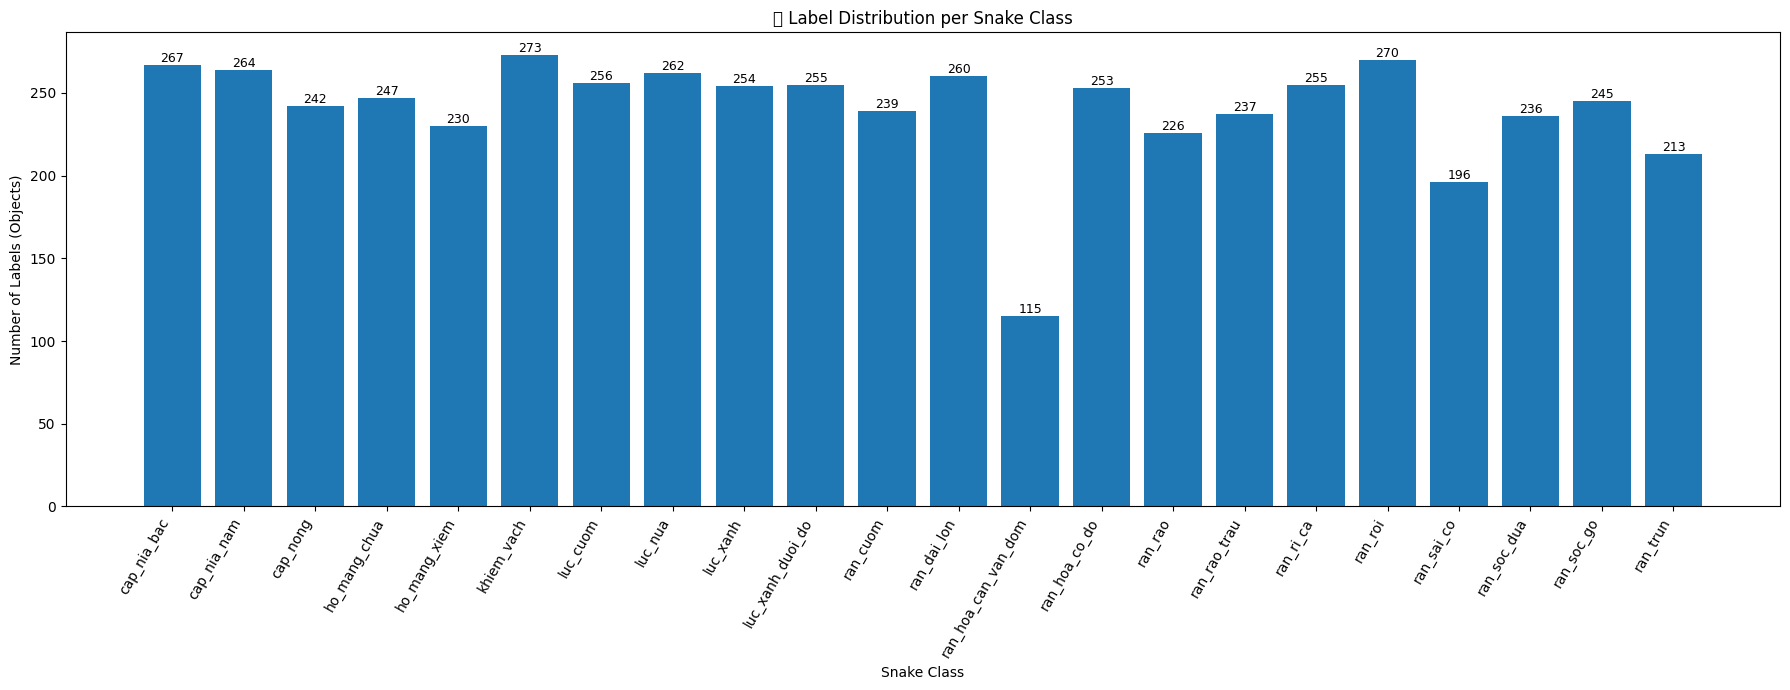

In [ ]:
import matplotlib.pyplot as plt

_, id2name = load_data_yaml(DATA_YAML)

data = []
for cid in range(len(id2name)):
    cname = id2name[cid]
    cnt = counts["objects_per_class"].get(cname, 0)
    data.append((cname, cnt))

# unpack
class_names, class_counts = zip(*data)

plt.figure(figsize=(18, 7))
bars = plt.bar(class_names, class_counts)

plt.xticks(rotation=60, ha="right")
plt.xlabel("Snake Class")
plt.ylabel("Number of Labels (Objects)")
plt.title("🐍 Label Distribution per Snake Class")

# Ghi số lên đầu cột
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        str(int(h)),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


In [ ]:
!pip -q install -U ultralytics pyyaml opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.7 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import numpy as np
from ultralytics import YOLO

In [ ]:
DATASET_ROOT = "/content/SnakeAid-YOLOv12-5291Bbox-Complete"
DATA_YAML = os.path.join(DATASET_ROOT, "data.yaml")

# Chọn model:
# - yolo11s.pt: cân bằng speed/accuracy, hợp lý cho 5k ảnh
# - yolo11m.pt: mạnh hơn nếu GPU đủ
MODEL_WEIGHTS = "yolo11m.pt"  # hoặc "yolo11m.pt"

In [ ]:
DRIVE_CKPT_DIR = "/content/drive/MyDrive/TrainSession"
os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)

DRIVE_LAST = os.path.join(DRIVE_CKPT_DIR, "snake_yolo_last.pt")  # ghi đè
DRIVE_BEST = os.path.join(DRIVE_CKPT_DIR, "snake_yolo_best.pt")  # ghi đè
SAVE_EVERY = 10  # mỗi 10 epoch

In [ ]:
# =========================
# LOSS SPIKE EARLY STOP
# =========================
class LossSpikeEarlyStop:
    """
    Stop training if loss spikes too much for N consecutive epochs.
    Ưu tiên val loss nếu có, fallback sang train loss.
    """
    def __init__(self, spike_ratio=0.35, spike_patience=2, warmup_epochs=5, prefer_val=True):
        self.spike_ratio = float(spike_ratio)
        self.spike_patience = int(spike_patience)
        self.warmup_epochs = int(warmup_epochs)
        self.prefer_val = bool(prefer_val)
        self.best = None
        self.spike_count = 0

    def _safe_float(self, x):
        try:
            return float(x)
        except Exception:
            return None

    def _get_loss(self, trainer):
        m = getattr(trainer, "metrics", {}) or {}

        val_keys = [
            "val/loss",
            "metrics/val/loss",
            "val/box_loss", "val/cls_loss", "val/dfl_loss",
            "metrics/val/box_loss", "metrics/val/cls_loss", "metrics/val/dfl_loss",
        ]

        if self.prefer_val:
            vals = [self._safe_float(m.get(k)) for k in val_keys]
            vals = [v for v in vals if v is not None]
            if vals:
                return float(np.sum(vals))

        loss_items = getattr(trainer, "loss_items", None)
        if loss_items is not None:
            try:
                return float(loss_items.sum().item())
            except Exception:
                try:
                    return float(sum(loss_items))
                except Exception:
                    pass

        tloss = getattr(trainer, "tloss", None)
        return self._safe_float(tloss) or 0.0

    def __call__(self, trainer):
        ep = int(getattr(trainer, "epoch", 0)) + 1
        loss_now = self._get_loss(trainer)

        if self.best is None:
            self.best = loss_now

        if ep <= self.warmup_epochs:
            self.best = min(self.best, loss_now)
            self.spike_count = 0
            return

        if loss_now < self.best:
            self.best = loss_now
            self.spike_count = 0
            return

        if loss_now > self.best * (1.0 + self.spike_ratio):
            self.spike_count += 1
        else:
            self.spike_count = 0

        if self.spike_count >= self.spike_patience:
            print(
                f"[LossSpikeEarlyStop] STOP at epoch {ep}: "
                f"loss={loss_now:.4f} > best={self.best:.4f} * (1+{self.spike_ratio})"
            )
            trainer.stop = True

# =========================
# BACKUP CALLBACK (MỖI 10 EPOCH)
# =========================
def backup_to_drive(trainer):
    ep = int(getattr(trainer, "epoch", 0)) + 1
    if ep % SAVE_EVERY != 0:
        return

    weights_dir = os.path.join(str(trainer.save_dir), "weights")
    last_pt = os.path.join(weights_dir, "last.pt")
    best_pt = os.path.join(weights_dir, "best.pt")

    if os.path.exists(last_pt):
        shutil.copy2(last_pt, DRIVE_LAST)

    if os.path.exists(best_pt):
        shutil.copy2(best_pt, DRIVE_BEST)

    print(f"[DRIVE BACKUP] Epoch {ep}: checkpoint saved to Drive")


In [ ]:
# =========================
# INIT MODEL + CALLBACKS
# =========================
model = YOLO(MODEL_WEIGHTS)

loss_spike_stop = LossSpikeEarlyStop(
    spike_ratio=0.35,
    spike_patience=2,
    warmup_epochs=5,
    prefer_val=True
)

In [ ]:
def on_fit_epoch_end(trainer):
    loss_spike_stop(trainer)
    backup_to_drive(trainer)

model.add_callback("on_fit_epoch_end", on_fit_epoch_end)

# =========================
# TRAIN
# =========================
results = model.train(
    data="/content/SnakeDataset/data.yaml",
    task="detect",
    epochs=120,
    imgsz=640,

    batch=32,          # nếu OOM -> 24 hoặc 16
    device=0,          # GPU L4
    workers=8,
    pretrained=True,

    optimizer="AdamW",
    lr0=0.002,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=3.0,
    weight_decay=0.0005,

    hsv_h=0.015,
    hsv_s=0.70,
    hsv_v=0.40,
    degrees=5.0,
    translate=0.10,
    scale=0.50,
    shear=2.0,
    perspective=0.0005,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.10,
    copy_paste=0.10,
    close_mosaic=10,

    amp=True,
    cache=True,
    val=True,

    patience=15,   # early stop chuẩn theo mAP/fitness
    seed=42,
    verbose=True
)

print("✅ Training done.")

Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/SnakeDataset/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=15, perspective=0.0005, plots=True, p

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/TrainSession/snake_yolo_last.pt")
model.train(resume=True)


Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/SnakeDataset/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/content/drive/MyDrive/TrainSession/snake_yolo_last.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, pa

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7db2b814bdd0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042, 

In [ ]:
import os
from datetime import datetime, timedelta, timezone

HOME = os.getcwd()
print(f"📂 HOME: {HOME}")

PROJECT_NAME = "SnakeTraining"
VERSION      = "H2"
MODEL_ARCH   = "YOLOv12"
AUTHOR       = "Hao"
DATA_INFO    = "Bbox5291Complete"

# Lấy thời gian hiện tại theo múi giờ UTC+7
utc_plus_7 = timezone(timedelta(hours=7))
current_time = datetime.now(utc_plus_7).strftime("%Y%m%d_%H%M")

# Ghép chuỗi tên model kèm timestamp
notebook_name = f"{PROJECT_NAME}_{VERSION}_{MODEL_ARCH}_{AUTHOR}_{DATA_INFO}_120epoch_10patience_{current_time}"

print(f"📘 Configured Model Name: {notebook_name}")

📂 HOME: /content
📘 Configured Model Name: SnakeTraining_H2_YOLOv12_Hao_Bbox5291Complete_120epoch_10patience_20251215_1346


In [ ]:
import shutil
import os

# Define the source path of the training directory
source_dir = f'{HOME}/runs/detect/train4'

# Define the destination base directory in Google Drive
drive_base_dir = '/content/drive/MyDrive/SnakeAIModels'
# The specific destination folder name comes from notebook_name
destination_dir = os.path.join(drive_base_dir, notebook_name)

print(f"💾 Saving entire training folder to: {destination_dir}")

# Copy the folder
if os.path.exists(source_dir):
    try:
        # shutil.copytree will create the destination_dir if it doesn't exist
        # dirs_exist_ok=True allows it to work even if the folder exists (e.g. re-run)
        shutil.copytree(source_dir, destination_dir, dirs_exist_ok=True)
        print(f"✅ Successfully copied training folder to Drive: {destination_dir}")
    except Exception as e:
        print(f"❌ Error during copy: {e}")
else:
    print(f"❌ Source folder {source_dir} not found. Did training finish?")

💾 Saving entire training folder to: /content/drive/MyDrive/SnakeAIModels/SnakeTraining_H2_YOLOv12_Hao_Bbox5291Complete_120epoch_10patience_20251215_1346
✅ Successfully copied training folder to Drive: /content/drive/MyDrive/SnakeAIModels/SnakeTraining_H2_YOLOv12_Hao_Bbox5291Complete_120epoch_10patience_20251215_1346


In [ ]:
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/SnakeAIModels/SnakeTraining_H2_YOLOv12_Hao_Bbox5291Complete_120epoch_10patience_20251215_1346/weights/best.pt"

model = YOLO(MODEL_PATH)
print("✅ Model loaded successfully")


✅ Model loaded successfully


In [ ]:
import os
import glob
from collections import Counter

from ultralytics import YOLO

# =========================
# CONFIG
# =========================
MODEL_PATH = "/content/drive/MyDrive/SnakeAIModels/SnakeTraining_H2_YOLOv12_Hao_Bbox5291Complete_120epoch_10patience_20251215_1346/weights/best.pt"

TEST_ROOT = "/content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5291Bbox-Complete/test"
IMG_DIR = os.path.join(TEST_ROOT, "images")
LBL_DIR = os.path.join(TEST_ROOT, "labels")

CONF_THRES = 0.25
IMGSZ = 640
DEVICE = 0

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# =========================
# LOAD MODEL
# =========================
model = YOLO(MODEL_PATH)
names = model.names  # class_id -> class_name

# =========================
# HELPERS
# =========================
def read_gt(label_path):
    """Return set of GT class names for an image."""
    if not os.path.exists(label_path):
        return set()
    txt = open(label_path, "r", encoding="utf-8", errors="ignore").read().strip()
    if not txt:
        return set()
    out = set()
    for line in txt.splitlines():
        try:
            cid = int(float(line.split()[0]))
            out.add(names[cid])
        except:
            pass
    return out

def top1_pred(result):
    """Return (class_name, conf) of top-1 prediction or (NONE, 0)."""
    if result.boxes is None or len(result.boxes) == 0:
        return "NONE", 0.0
    confs = result.boxes.conf.cpu().numpy()
    idx = confs.argmax()
    cid = int(result.boxes.cls[idx])
    return names[cid], float(confs[idx])

# =========================
# COLLECT IMAGES
# =========================
image_paths = []
for ext in IMG_EXTS:
    image_paths += glob.glob(os.path.join(IMG_DIR, f"*{ext}"))
image_paths = sorted(image_paths)

print("Total test images:", len(image_paths))

# =========================
# EVALUATION
# =========================
total = 0
correct = 0
miss = 0
wrong = 0

per_class_correct = Counter()
per_class_total = Counter()

for img_path in image_paths:
    stem = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(LBL_DIR, stem + ".txt")

    gt_set = read_gt(label_path)

    results = model.predict(
        source=img_path,
        imgsz=IMGSZ,
        conf=CONF_THRES,
        device=DEVICE,
        verbose=False
    )

    pred_name, pred_conf = top1_pred(results[0])

    total += 1

    # Count GT occurrences
    for g in gt_set:
        per_class_total[g] += 1

    if not gt_set:
        miss += 1
        continue

    if pred_name == "NONE":
        miss += 1
        continue

    if pred_name in gt_set:
        correct += 1
        per_class_correct[pred_name] += 1
    else:
        wrong += 1

# =========================
# RESULTS
# =========================
accuracy = correct / total if total > 0 else 0.0

print("\n===== IMAGE-LEVEL ACCURACY =====")
print(f"Total test images : {total}")
print(f"Correct predictions: {correct}")
print(f"Wrong predictions  : {wrong}")
print(f"Miss (no detect)   : {miss}")
print(f"Accuracy           : {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\n===== PER-CLASS CORRECT (Top-1) =====")
for cls, cnt in per_class_correct.most_common():
    print(f"{cls:25s}: {cnt}/{per_class_total[cls]}")


Total test images: 231


In [ ]:
import os
import glob
import csv
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from ultralytics import YOLO

# =========================
# CONFIG
# =========================
MODEL_PATH = "/content/drive/MyDrive/SnakeAIModels/SnakeTraining_H2_YOLOv12_Hao_Bbox5291Complete_120epoch_10patience_20251215_1346/weights/best.pt"

TEST_ROOT = "/content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5291Bbox-Complete/test"  # chứa images/ và labels/
IMG_DIR = os.path.join(TEST_ROOT, "images")
LBL_DIR = os.path.join(TEST_ROOT, "labels")

CONF_THRES = 0.25
IOU_THRES = 0.5
IMGSZ = 640
DEVICE = 0

assert os.path.exists(MODEL_PATH), f"Model not found: {MODEL_PATH}"
assert os.path.isdir(IMG_DIR), f"Images dir not found: {IMG_DIR}"
assert os.path.isdir(LBL_DIR), f"Labels dir not found: {LBL_DIR}"

# =========================
# LOAD MODEL
# =========================
model = YOLO(MODEL_PATH)
names = model.names  # id -> class name

# =========================
# HELPERS
# =========================
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def read_gt_classes(label_path: str):
    """Return list of class_ids in label file (may have multiple objects)."""
    if not os.path.exists(label_path):
        return []
    txt = open(label_path, "r", encoding="utf-8", errors="ignore").read().strip()
    if not txt:
        return []
    cls_ids = []
    for line in txt.splitlines():
        parts = line.strip().split()
        if len(parts) < 1:
            continue
        try:
            cls_ids.append(int(float(parts[0])))
        except:
            continue
    return cls_ids

def unique_names_from_ids(ids):
    return sorted({names[i] for i in ids if i in names})

def preds_from_result(r):
    """Return list of (class_name, conf) for each predicted box."""
    out = []
    if r.boxes is None or len(r.boxes) == 0:
        return out
    for b in r.boxes:
        cid = int(b.cls[0])
        conf = float(b.conf[0])
        out.append((names.get(cid, str(cid)), conf))
    # sort high conf first
    out.sort(key=lambda x: x[1], reverse=True)
    return out

def show_image(path, title=""):
    img = mpimg.imread(path)
    plt.figure(figsize=(10, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

# =========================
# RUN EVAL PER IMAGE
# =========================
image_paths = []
for ext in IMG_EXTS:
    image_paths += glob.glob(os.path.join(IMG_DIR, f"*{ext}"))
image_paths = sorted(image_paths)

print("Total test images:", len(image_paths))

rows = []
gt_counter = Counter()
pred_counter = Counter()
match_counter = Counter()

for idx, img_path in enumerate(image_paths, 1):
    stem = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(LBL_DIR, stem + ".txt")

    # ---- GT ----
    gt_ids = read_gt_classes(label_path)
    gt_names = unique_names_from_ids(gt_ids)

    # ---- Predict ----
    results = model.predict(
        source=img_path,
        imgsz=IMGSZ,
        conf=CONF_THRES,
        iou=IOU_THRES,
        device=DEVICE,
        save=False,
        verbose=False
    )

    r = results[0]
    pred_list = preds_from_result(r)
    pred_names = sorted({p[0] for p in pred_list})

    # Update counters
    for g in gt_names:
        gt_counter[g] += 1
    for p in pred_names:
        pred_counter[p] += 1

    # Basic match logic:
    # - If GT has 1 class, we compare with top-1 predicted class (highest conf)
    # - If GT has multiple classes, we count match if any predicted class intersects GT set
    top1 = pred_list[0][0] if pred_list else "NONE"
    top1_conf = pred_list[0][1] if pred_list else 0.0

    if len(gt_names) == 0:
        verdict = "NO_GT_LABEL"
    elif top1 == "NONE":
        verdict = "MISS"
    else:
        if len(gt_names) == 1:
            verdict = "OK" if top1 == gt_names[0] else "WRONG"
        else:
            verdict = "OK" if top1 in set(gt_names) else "WRONG_MULTI"

    match_counter[verdict] += 1

    # ---- Print per image summary ----
    print(f"\n[{idx}/{len(image_paths)}] {os.path.basename(img_path)}")
    print("  GT   :", gt_names if gt_names else ["(no label/empty)"])
    print("  Pred :", pred_list[:5] if pred_list else ["(no detection)"])
    print(f"  Top1 : {top1} ({top1_conf:.3f})  => {verdict}")

    # ---- Show annotated image (draw boxes) ----
    # Ultralytics can plot the result to numpy image
    plotted = r.plot()  # BGR numpy
    # Convert BGR->RGB for matplotlib
    plotted = plotted[..., ::-1]

    plt.figure(figsize=(10, 7))
    plt.imshow(plotted)
    plt.axis("off")
    plt.title(f"{os.path.basename(img_path)} | GT={gt_names} | Top1={top1}({top1_conf:.2f}) | {verdict}")
    plt.show()

    # ---- Save row ----
    rows.append({
        "image": img_path,
        "gt_classes": ",".join(gt_names),
        "pred_top1": top1,
        "pred_top1_conf": f"{top1_conf:.4f}",
        "pred_all": ";".join([f"{c}:{conf:.3f}" for c, conf in pred_list[:10]]),
        "verdict": verdict
    })

# =========================
# SUMMARY
# =========================
print("\n=== SUMMARY VERDICT COUNTS ===")
for k, v in match_counter.items():
    print(f"{k:12s}: {v}")

# (Optional) Save CSV
OUT_CSV = os.path.join(TEST_ROOT, "pred_vs_gt_test.csv")
with open(OUT_CSV, "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys()) if rows else ["image"])
    w.writeheader()
    if rows:
        w.writerows(rows)
print("\n✅ Saved CSV:", OUT_CSV)
